In [ ]:
import sys

!{sys.executable} bridge_shm_unsupervised_preprocess_v2.py \
  --input_csv "data/民生桥_20251201_20260318.csv" \
  --output_dir "outputs/single_民生桥" \
  --epochs 60 \
  --window_size 12 \
  --stride 1 \
  --latent_dim 32 \
  --plot_top_k 4

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

bridge_name = "民生桥"
raw_path = f"data/{bridge_name}_20251201_20260318.csv"
out_dir = f"outputs/single_{bridge_name}"

raw = pd.read_csv(raw_path, encoding="utf-8-sig")
clean = pd.read_csv(os.path.join(out_dir, "cleaned_data.csv"), encoding="utf-8-sig")
score = pd.read_csv(os.path.join(out_dir, "score_data.csv"), encoding="utf-8-sig")
health = pd.read_csv(os.path.join(out_dir, "sensor_health_summary.csv"), encoding="utf-8-sig")
metrics = pd.read_csv(os.path.join(out_dir, "bridge_test_metrics.csv"), encoding="utf-8-sig")

# 自动找时间列
if pd.api.types.is_datetime64_any_dtype(pd.to_datetime(raw.iloc[:,0], errors='coerce')):
    t = pd.to_datetime(raw.iloc[:,0], errors='coerce')
else:
    t = np.arange(len(raw))

# 选缺失率最高的一个传感器看修复效果
sensor_cols = [c for c in raw.columns[1:] if c in clean.columns]
missing_rate = raw[sensor_cols].isna().mean().sort_values(ascending=False)
sensor = missing_rate.index[0] if len(missing_rate) else sensor_cols[0]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 图1：原始 vs 清洗
axes[0,0].plot(t, raw[sensor], label='Raw', lw=1)
axes[0,0].plot(t, clean[sensor], label='Cleaned', lw=1)
axes[0,0].set_title(f'{bridge_name} - 传感器 {sensor} 原始/清洗对比')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# 图2：质量分数时间序列
score_col = [c for c in score.columns if 'score' in c.lower()]
score_col = score_col[0] if score_col else score.columns[-1]
axes[0,1].plot(score[score_col], color='tab:orange', lw=1)
axes[0,1].set_title(f'{bridge_name} - 综合质量分数 ({score_col})')
axes[0,1].grid(alpha=0.3)

# 图3：传感器健康度 Top10（最差）
if 'device_health' in health.columns:
    hcol = 'device_health'
else:
    num_cols = health.select_dtypes(include=[np.number]).columns
    hcol = num_cols[0]

h = health[[health.columns[0], hcol]].copy().sort_values(hcol, ascending=True).head(10)
axes[1,0].barh(h.iloc[:,0].astype(str), h[hcol], color='tab:red', alpha=0.8)
axes[1,0].set_title(f'{bridge_name} - 健康度最低10个传感器')
axes[1,0].set_xlabel(hcol)

# 图4：桥级指标表格
axes[1,1].axis('off')
show_df = metrics.copy().T
axes[1,1].table(cellText=show_df.values,
                rowLabels=show_df.index,
                colLabels=show_df.columns,
                loc='center')
axes[1,1].set_title(f'{bridge_name} - 桥级测试指标')

plt.tight_layout()
os.makedirs("outputs/report_figs", exist_ok=True)
fig.savefig(f"outputs/report_figs/{bridge_name}_single_report.png", dpi=180)
plt.show()
print(f"Saved: outputs/report_figs/{bridge_name}_single_report.png")

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/single_民生桥\\cleaned_data.csv'

In [10]:
import os
import glob
import subprocess
import sys

script = "bridge_shm_unsupervised_preprocess_v2.py"
all_csv = sorted(glob.glob("data/*.csv"))

for csv_path in all_csv:
    bridge = os.path.basename(csv_path).replace("_20251201_20260318.csv", "")
    out_dir = f"outputs/multi/{bridge}"
    os.makedirs(out_dir, exist_ok=True)

    cmd = [
        sys.executable, script,
        "--input_csv", csv_path,
        "--output_dir", out_dir,
        "--epochs", "60",
        "--window_size", "12",
        "--stride", "1",
        "--latent_dim", "32",
        "--plot_top_k", "4",
    ]

    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

print("全部桥梁处理完成。")

Running: d:\software\miniconda\envs\automl\python.exe bridge_shm_unsupervised_preprocess_v2.py --input_csv data\大岗沥大桥_20251201_20260318.csv --output_dir outputs/multi/大岗沥大桥 --epochs 60 --window_size 12 --stride 1 --latent_dim 32 --plot_top_k 4
Running: d:\software\miniconda\envs\automl\python.exe bridge_shm_unsupervised_preprocess_v2.py --input_csv data\子沙大桥_20251201_20260318.csv --output_dir outputs/multi/子沙大桥 --epochs 60 --window_size 12 --stride 1 --latent_dim 32 --plot_top_k 4
Running: d:\software\miniconda\envs\automl\python.exe bridge_shm_unsupervised_preprocess_v2.py --input_csv data\新榄核大桥_20251201_20260318.csv --output_dir outputs/multi/新榄核大桥 --epochs 60 --window_size 12 --stride 1 --latent_dim 32 --plot_top_k 4
Running: d:\software\miniconda\envs\automl\python.exe bridge_shm_unsupervised_preprocess_v2.py --input_csv data\新浅海大桥_20251201_20260318.csv --output_dir outputs/multi/新浅海大桥 --epochs 60 --window_size 12 --stride 1 --latent_dim 32 --plot_top_k 4
Running: d:\software\minic

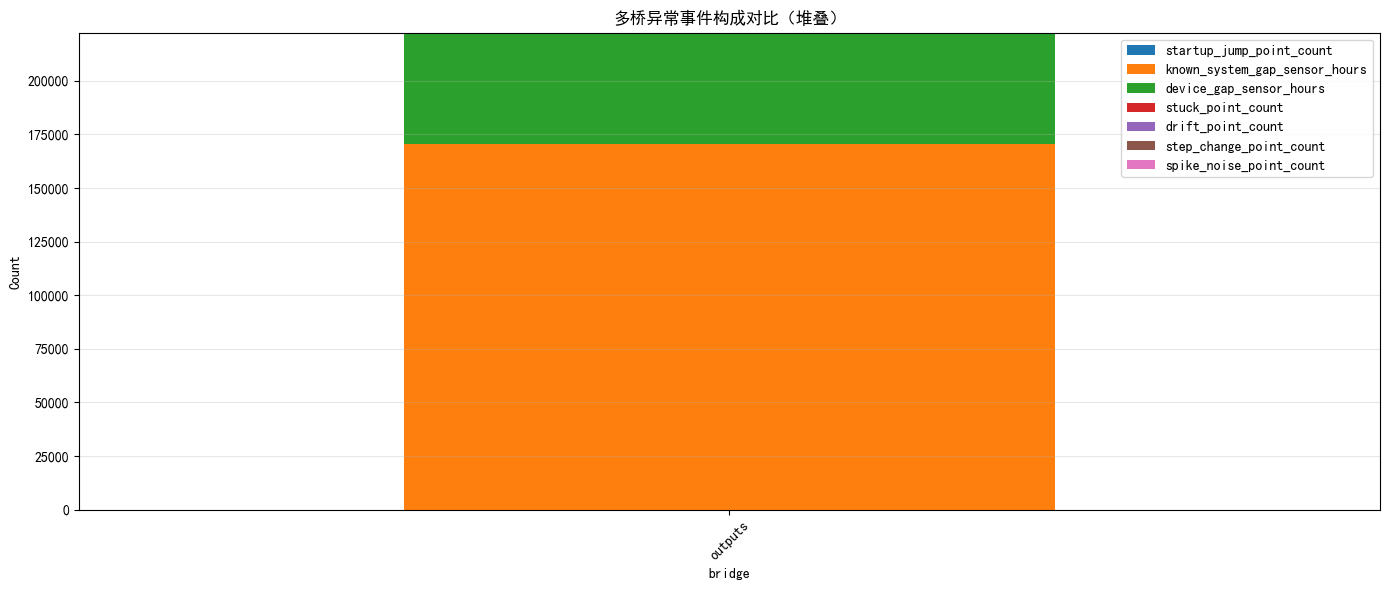

Saved: outputs/report_figs/multi_bridge_event_compare.png


In [11]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

metric_files = sorted(glob.glob("outputs/multi/*/bridge_test_metrics.csv"))
event_files = sorted(glob.glob("outputs/multi/*/bridge_event_summary.csv"))

all_metrics = []
for f in metric_files:
    bridge = f.split("/")[-2]
    df = pd.read_csv(f, encoding="utf-8-sig")
    df.insert(0, "bridge", bridge)
    all_metrics.append(df)

metric_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()

all_events = []
for f in event_files:
    bridge = f.split("/")[-2]
    df = pd.read_csv(f, encoding="utf-8-sig")
    df.insert(0, "bridge", bridge)
    all_events.append(df)

event_df = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()

os.makedirs("outputs/report_figs", exist_ok=True)
metric_df.to_csv("outputs/report_figs/all_bridge_metrics.csv", index=False, encoding="utf-8-sig")
event_df.to_csv("outputs/report_figs/all_bridge_events.csv", index=False, encoding="utf-8-sig")

# 选常见指标列（若不存在自动跳过）
candidates = [
    "bridge_device_health",
    "bridge_availability",
    "abnormal_point_ratio",
    "mean_score",
    "p95_score",
]
use_cols = [c for c in candidates if c in metric_df.columns]

if len(metric_df) > 0 and len(use_cols) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # 图A：健康度/可用率柱状图
    bar_cols = [c for c in ["bridge_device_health", "bridge_availability"] if c in metric_df.columns]
    if bar_cols:
        plot_df = metric_df[["bridge"] + bar_cols].set_index("bridge")
        plot_df.plot(kind="bar", ax=axes[0], rot=45)
        axes[0].set_title("多桥健康度与可用率对比")
        axes[0].set_ylabel("Score / %")
        axes[0].grid(axis='y', alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, "无健康度/可用率字段", ha='center', va='center')
        axes[0].axis('off')

    # 图B：综合指标热力图（标准化）
    heat_df = metric_df[["bridge"] + use_cols].set_index("bridge")
    norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min() + 1e-9)
    im = axes[1].imshow(norm.values, aspect='auto', cmap='RdYlGn')
    axes[1].set_title("多桥综合指标热力图（归一化）")
    axes[1].set_xticks(range(len(use_cols)))
    axes[1].set_xticklabels(use_cols, rotation=30, ha='right')
    axes[1].set_yticks(range(len(norm.index)))
    axes[1].set_yticklabels(norm.index)
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    fig.savefig("outputs/report_figs/multi_bridge_compare.png", dpi=180)
    plt.show()
    print("Saved: outputs/report_figs/multi_bridge_compare.png")

# 事件统计图（可选）
if len(event_df) > 0:
    num_cols = [c for c in event_df.columns if c != "bridge" and pd.api.types.is_numeric_dtype(event_df[c])]
    if num_cols:
        agg = event_df.groupby("bridge")[num_cols].sum().sort_index()
        fig = plt.figure(figsize=(14, 6))
        agg.plot(kind="bar", stacked=True, ax=plt.gca(), rot=45)
        plt.title("多桥异常事件构成对比（堆叠）")
        plt.ylabel("Count")
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig("outputs/report_figs/multi_bridge_event_compare.png", dpi=180)
        plt.show()
        print("Saved: outputs/report_figs/multi_bridge_event_compare.png")